# Project 2: Fraud Detection Pipeline (Supervised Learning)
**DecodeLabs Industrial Training Kit — Batch 2026**

## Import libraries and load the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset for Data Analytics.csv")

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Explore the data (EDA)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [ ]:
# Check for missing values
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [ ]:
# Basic statistics for the number columns
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [ ]:
# Sanity check: TotalPrice should equal Quantity x UnitPrice
mismatch = (abs(df["Quantity"] * df["UnitPrice"] - df["TotalPrice"]) > 0.01).sum()
print("Rows where TotalPrice is wrong:", mismatch)

Rows where TotalPrice is wrong: 0


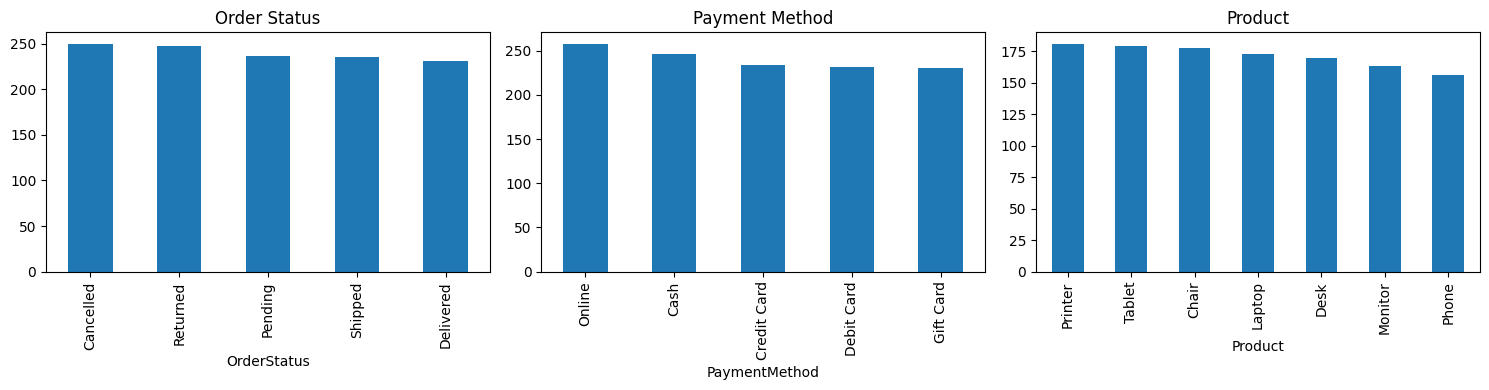

In [ ]:
# Look at the categorical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["OrderStatus"].value_counts().plot(kind="bar", ax=axes[0], title="Order Status")
df["PaymentMethod"].value_counts().plot(kind="bar", ax=axes[1], title="Payment Method")
df["Product"].value_counts().plot(kind="bar", ax=axes[2], title="Product")
plt.tight_layout()
plt.show()

## Clean the data

In [ ]:
# Fill missing coupon codes - missing means the customer used no coupon
df["CouponCode"] = df["CouponCode"].fillna("NONE")

# Convert Date to a real date and extract useful parts
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek  

df.isna().sum().sum()  

np.int64(0)

## Create the fraud label

In [ ]:
df["Fraud"] = 0

risky_payment = df["PaymentMethod"].isin(["Gift Card", "Online"])
bad_status = df["OrderStatus"].isin(["Cancelled", "Returned"])
big_order = (df["Quantity"] >= 4) & (df["TotalPrice"] > 1500)

df.loc[risky_payment & bad_status & big_order, "Fraud"] = 1

print(df["Fraud"].value_counts())
print("Fraud rate:", round(df["Fraud"].mean() * 100, 2), "%")

Fraud
0    1158
1      42
Name: count, dtype: int64
Fraud rate: 3.5 %


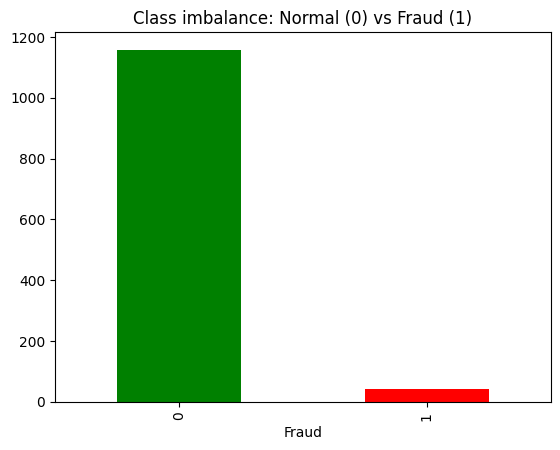

In [ ]:
# Visualise the imbalance
df["Fraud"].value_counts().plot(kind="bar", color=["green", "red"], title="Class imbalance: Normal (0) vs Fraud (1)")
plt.show()

## Prepare the features

In [ ]:
drop_cols = ["OrderID", "CustomerID", "ShippingAddress", "TrackingNumber", "Date", "Fraud"]
X = df.drop(columns=drop_cols)
y = df["Fraud"]

X = pd.get_dummies(X, columns=["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"])

print("Number of features:", X.shape[1])
X.head()

Number of features: 32


,Quantity,UnitPrice,ItemsInCart,TotalPrice,Month,DayOfWeek,Product_Chair,Product_Desk,Product_Laptop,Product_Monitor,...,OrderStatus_Shipped,CouponCode_FREESHIP,CouponCode_NONE,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Email,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,5,570.62,7,2853.10,1,2,False,False,False,True,...,True,False,False,True,False,False,False,False,True,False
1,2,151.35,3,302.70,8,4,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
2,5,550.68,8,2753.40,2,1,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
3,1,273.19,5,273.19,10,6,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,4,626.01,8,2504.04,5,3,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False


## Split into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set:", X_train.shape[0], "orders,", y_train.sum(), "fraud")
print("Test set:    ", X_test.shape[0], "orders,", y_test.sum(), "fraud")

Training set: 960 orders, 34 fraud
Test set:     240 orders, 8 fraud


## Scale the features


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

## Handle the imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 926, 1: 34}
After SMOTE:  {0: 926, 1: 926}


## Train the models

We train two classifiers on the balanced training data:

1. Logistic Regression
2. Random Forest

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_bal, y_train_bal)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train_bal, y_train_bal)

print("Both models trained!")

Both models trained!


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve)

results = {}
for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf)]:
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of fraud
    results[name] = {
        "Accuracy (misleading!)": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }

pd.DataFrame(results).round(3)

,Logistic Regression,Random Forest
Accuracy (misleading!),0.988,0.992
Precision,0.727,1.000
Recall,1.000,0.750
ROC-AUC,0.997,0.982


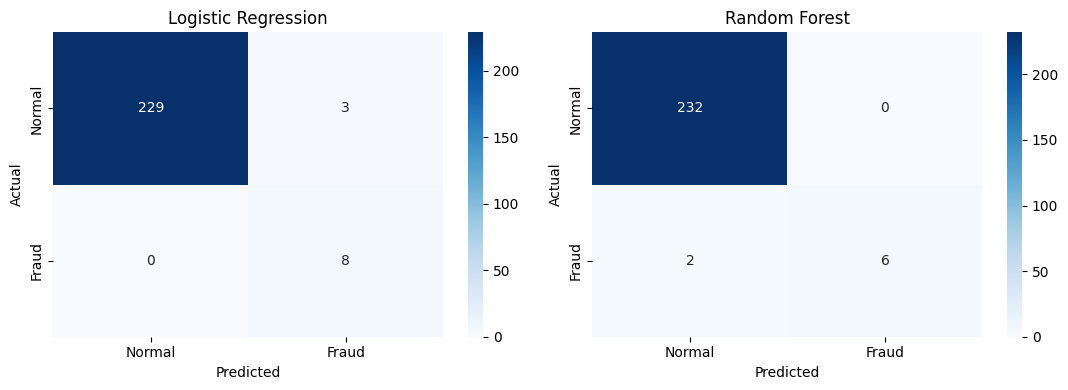

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, [("Logistic Regression", log_reg), ("Random Forest", rf)]):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

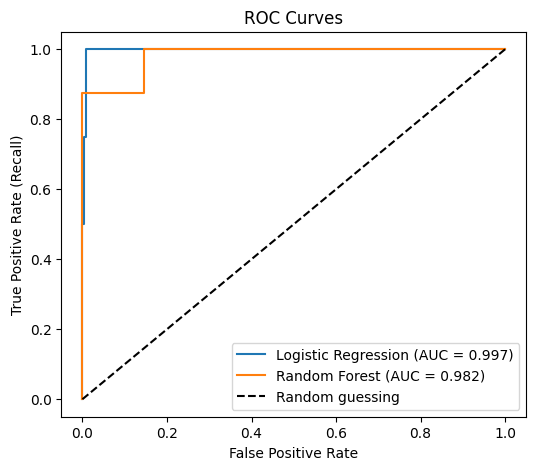

In [ ]:
# ROC curves
plt.figure(figsize=(6, 5))
for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf)]:
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves")
plt.legend()
plt.show()

## Hyperparameter tuning



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, scoring="roc_auc", cv=3)
grid.fit(X_train_bal, y_train_bal)

print("Best settings:", grid.best_params_)

best_rf = grid.best_estimator_
proba = best_rf.predict_proba(X_test_scaled)[:, 1]
print("Tuned Random Forest ROC-AUC on test set:", round(roc_auc_score(y_test, proba), 3))

Best settings: {'max_depth': 10, 'n_estimators': 100}
Tuned Random Forest ROC-AUC on test set: 0.985


## Which features matter most?

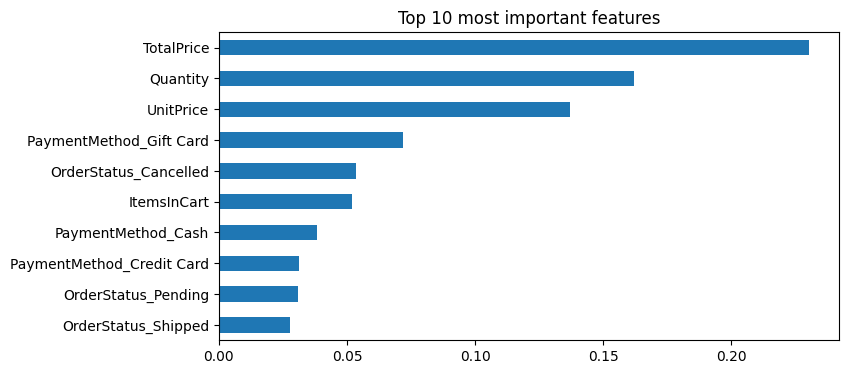

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10).plot(kind="barh", figsize=(8, 4), title="Top 10 most important features")
plt.gca().invert_yaxis()
plt.show()